In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)

Project root: c:\Users\mohit\OneDrive\Desktop\AI HealthCare
Data directory: c:\Users\mohit\OneDrive\Desktop\AI HealthCare\data\raw
Model directory: c:\Users\mohit\OneDrive\Desktop\AI HealthCare\models


In [3]:
DATASET_PATH = DATA_DIR / "Diseases_and_Symptoms_dataset.csv"

df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (96088, 231)


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,irregular heartbeat,breathing fast,hoarse voice,sore throat,difficulty speaking,cough,nasal congestion,throat swelling,diminished hearing,difficulty in swallowing,skin swelling,retention of urine,leg pain,hip pain,suprapubic pain,blood in stool,lack of growth,symptoms of the scrotum and testes,swelling of scrotum,pain in testicles,pus draining from ear,jaundice,white discharge from eye,irritable infant,abusing alcohol,fainting,hostile behavior,drug abuse,sharp abdominal pain,feeling ill,vomiting,headache,nausea,diarrhea,vaginal itching,painful urination,involuntary urination,pain during intercourse,frequent urination,lower abdominal pain,vaginal discharge,blood in urine,hot flashes,intermenstrual bleeding,hand or finger pain,wrist pain,hand or finger swelling,arm pain,wrist swelling,arm stiffness or tightness,arm swelling,hand or finger stiffness or tightness,lip swelling,toothache,abnormal appearing skin,skin lesion,acne or pimples,facial pain,mouth ulcer,skin growth,diminished vision,double vision,symptoms of eye,pain in eye,abnormal movement of eyelid,foreign body sensation in eye,irregular appearing scalp,back pain,neck pain,low back pain,pain of the anus,pain during pregnancy,pelvic pain,impotence,vomiting blood,regurgitation,burning abdominal pain,restlessness,wheezing,peripheral edema,neck mass,ear pain,jaw swelling,mouth dryness,neck swelling,knee pain,foot or toe pain,ankle pain,bones are painful,elbow pain,knee swelling,skin moles,weight gain,problems with movement,knee stiffness or tightness,leg swelling,foot or toe swelling,heartburn,infant feeding problem,vaginal pain,vaginal redness,weakness,decreased heart rate,increased heart rate,ringing in ear,plugged feeling in ear,itchy ear(s),frontal headache,fluid in ear,spots or clouds in vision,eye redness,lacrimation,itchiness of eye,blindness,eye burns or stings,decreased appetite,excessive anger,loss of sensation,focal weakness,symptoms of the face,disturbance of memory,paresthesia,side pain,fever,shoulder pain,shoulder stiffness or tightness,ache all over,lower body pain,problems during pregnancy,spotting or bleeding during pregnancy,cramps and spasms,upper abdominal pain,stomach bloating,changes in stool appearance,unusual color or odor to urine,kidney mass,symptoms of prostate,difficulty breathing,rib pain,joint pain,hand or finger lump or mass,chills,groin pain,fatigue,regurgitation.1,symptoms of the kidneys,melena,coughing up sputum,seizures,delusions or hallucinations,excessive urination at night,bleeding from eye,rectal bleeding,constipation,temper problems,coryza,hemoptysis,allergic reaction,congestion in chest,sleepiness,apnea,abnormal breathing sounds,blood clots during menstrual periods,pulling at ears,gum pain,redness in ear,fluid retention,flu-like syndrome,sinus congestion,painful sinuses,fears and phobias,recent pregnancy,uterine contractions,burning chest pain,back cramps or spasms,back mass or lump,nosebleed,long menstrual periods,heavy menstrual flow,unpredictable menstruation,painful menstruation,infertility,frequent menstruation,sweating,mass on eyelid,swollen eye,eyelid swelling,eyelid lesion or rash,symptoms of bladder,irregular appearing nails,itching of skin,hurts to breath,"skin dryness, peeling, scaliness, or roughness",skin irritation,itchy scalp,warts,skin rash,mass or swelling around the anus,ankle swelling,elbow swelling,bleeding from ear,hand or finger weakness,low self-esteem,itching of the anus,swollen or red tonsils,hip stiffness or tightness,mouth pain,arm weakness,obsessions and compulsions,antisocial behavior,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
0,panic disorder,1,0,1,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes.value_counts())

Dataset Shape: (96088, 231)

Column Names:
['diseases', 'anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness', 'palpitations', 'irregular heartbeat', 'breathing fast', 'hoarse voice', 'sore throat', 'difficulty speaking', 'cough', 'nasal congestion', 'throat swelling', 'diminished hearing', 'difficulty in swallowing', 'skin swelling', 'retention of urine', 'leg pain', 'hip pain', 'suprapubic pain', 'blood in stool', 'lack of growth', 'symptoms of the scrotum and testes', 'swelling of scrotum', 'pain in testicles', 'pus draining from ear', 'jaundice', 'white discharge from eye', 'irritable infant', 'abusing alcohol', 'fainting', 'hostile behavior', 'drug abuse', 'sharp abdominal pain', 'feeling ill', 'vomiting', 'headache', 'nausea', 'diarrhea', 'vaginal itching', 'painful urination', 'involuntary urination', 'pain during intercourse', 'frequent 

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,irregular heartbeat,breathing fast,hoarse voice,sore throat,difficulty speaking,cough,nasal congestion,throat swelling,diminished hearing,difficulty in swallowing,skin swelling,retention of urine,leg pain,hip pain,suprapubic pain,blood in stool,lack of growth,symptoms of the scrotum and testes,swelling of scrotum,pain in testicles,pus draining from ear,jaundice,white discharge from eye,irritable infant,abusing alcohol,fainting,hostile behavior,drug abuse,sharp abdominal pain,feeling ill,vomiting,headache,nausea,diarrhea,vaginal itching,painful urination,involuntary urination,pain during intercourse,frequent urination,lower abdominal pain,vaginal discharge,blood in urine,hot flashes,intermenstrual bleeding,hand or finger pain,wrist pain,hand or finger swelling,arm pain,wrist swelling,arm stiffness or tightness,arm swelling,hand or finger stiffness or tightness,lip swelling,toothache,abnormal appearing skin,skin lesion,acne or pimples,facial pain,mouth ulcer,skin growth,diminished vision,double vision,symptoms of eye,pain in eye,abnormal movement of eyelid,foreign body sensation in eye,irregular appearing scalp,back pain,neck pain,low back pain,pain of the anus,pain during pregnancy,pelvic pain,impotence,vomiting blood,regurgitation,burning abdominal pain,restlessness,wheezing,peripheral edema,neck mass,ear pain,jaw swelling,mouth dryness,neck swelling,knee pain,foot or toe pain,ankle pain,bones are painful,elbow pain,knee swelling,skin moles,weight gain,problems with movement,knee stiffness or tightness,leg swelling,foot or toe swelling,heartburn,infant feeding problem,vaginal pain,vaginal redness,weakness,decreased heart rate,increased heart rate,ringing in ear,plugged feeling in ear,itchy ear(s),frontal headache,fluid in ear,spots or clouds in vision,eye redness,lacrimation,itchiness of eye,blindness,eye burns or stings,decreased appetite,excessive anger,loss of sensation,focal weakness,symptoms of the face,disturbance of memory,paresthesia,side pain,fever,shoulder pain,shoulder stiffness or tightness,ache all over,lower body pain,problems during pregnancy,spotting or bleeding during pregnancy,cramps and spasms,upper abdominal pain,stomach bloating,changes in stool appearance,unusual color or odor to urine,kidney mass,symptoms of prostate,difficulty breathing,rib pain,joint pain,hand or finger lump or mass,chills,groin pain,fatigue,regurgitation.1,symptoms of the kidneys,melena,coughing up sputum,seizures,delusions or hallucinations,excessive urination at night,bleeding from eye,rectal bleeding,constipation,temper problems,coryza,hemoptysis,allergic reaction,congestion in chest,sleepiness,apnea,abnormal breathing sounds,blood clots during menstrual periods,pulling at ears,gum pain,redness in ear,fluid retention,flu-like syndrome,sinus congestion,painful sinuses,fears and phobias,recent pregnancy,uterine contractions,burning chest pain,back cramps or spasms,back mass or lump,nosebleed,long menstrual periods,heavy menstrual flow,unpredictable menstruation,painful menstruation,infertility,frequent menstruation,sweating,mass on eyelid,swollen eye,eyelid swelling,eyelid lesion or rash,symptoms of bladder,irregular appearing nails,itching of skin,hurts to breath,"skin dryness, peeling, scaliness, or roughness",skin irritation,itchy scalp,warts,skin rash,mass or swelling around the anus,ankle swelling,elbow swelling,bleeding from ear,hand or finger weakness,low self-esteem,itching of the anus,swollen or red tonsils,hip stiffness or tightness,mouth pain,arm weakness,obsessions and compulsions,antisocial behavior,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
0,panic disorder,1,0,1,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Data Types:
int64     230
object      1
Name: count, dtype: int64


In [5]:
# Check missing values
total_missing = df.isnull().sum().sum()

# Check duplicate rows
total_duplicates = df.duplicated().sum()

# Check number of unique diseases
unique_diseases = df["diseases"].nunique()

# Check unique values present in symptom columns
symptom_columns = df.columns.drop("diseases")
unique_symptom_values = np.unique(df[symptom_columns].values)

print("Total Missing Values:", total_missing)
print("Duplicate Rows:", total_duplicates)
print("Number of Unique Diseases:", unique_diseases)
print("Unique Symptom Values:", unique_symptom_values)

Total Missing Values: 0
Duplicate Rows: 0
Number of Unique Diseases: 100
Unique Symptom Values: [0 1]


In [6]:
disease_counts = df["diseases"].value_counts()

print("Disease Class Distribution:")
display(disease_counts)

print("\nMinimum samples in a disease:", disease_counts.min())
print("Maximum samples in a disease:", disease_counts.max())
print("Average samples per disease:", round(disease_counts.mean(), 2))

Disease Class Distribution:


diseases
cystitis                              1219
vulvodynia                            1218
nose disorder                         1218
complex regional pain syndrome        1217
spondylosis                           1216
                                      ... 
hypertensive heart disease             804
gum disease                            803
allergy                                803
injury to the trunk                    803
temporary or benign blood in urine     803
Name: count, Length: 100, dtype: int64


Minimum samples in a disease: 803
Maximum samples in a disease: 1219
Average samples per disease: 960.88


In [7]:
X = df.drop(columns=["diseases"])
y = df["diseases"]

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

print("\nX data type:")
print(X.dtypes.value_counts())

print("\nFirst 5 target values:")
display(y.head())

Feature matrix X shape: (96088, 230)
Target vector y shape: (96088,)

X data type:
int64    230
Name: count, dtype: int64

First 5 target values:


0    panic disorder
1    panic disorder
2    panic disorder
3    panic disorder
4    panic disorder
Name: diseases, dtype: object

In [8]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original target:")
print(y.head().tolist())

print("\nEncoded target:")
print(y_encoded[:5])

print("\nNumber of encoded classes:", len(label_encoder.classes_))

Original target:
['panic disorder', 'panic disorder', 'panic disorder', 'panic disorder', 'panic disorder']

Encoded target:
[71 71 71 71 71]

Number of encoded classes: 100


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (76870, 230)
Testing feature shape: (19218, 230)
Training target shape: (76870,)
Testing target shape: (19218,)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB

#Logistic Regression

In [11]:
import time

start_time = time.time()

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

training_time = time.time() - start_time

print("Logistic Regression trained successfully!")
print(f"Training Time: {training_time:.2f} seconds")

Logistic Regression trained successfully!
Training Time: 15.00 seconds


In [12]:
y_pred_logistic = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {logistic_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 0.8985
Logistic Regression Accuracy: 89.85%


#Bernoulli Naive Bayes

In [13]:
start_time = time.time()

nb_model = BernoulliNB()

nb_model.fit(X_train, y_train)

nb_training_time = time.time() - start_time

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Bernoulli Naive Bayes trained successfully!")
print(f"Training Time: {nb_training_time:.2f} seconds")
print(f"Bernoulli NB Accuracy: {nb_accuracy:.4f}")
print(f"Bernoulli NB Accuracy: {nb_accuracy * 100:.2f}%")

Bernoulli Naive Bayes trained successfully!
Training Time: 15.20 seconds
Bernoulli NB Accuracy: 0.8985
Bernoulli NB Accuracy: 89.85%


#Decision Tree

In [14]:
start_time = time.time()

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

dt_training_time = time.time() - start_time

y_pred_dt = decision_tree_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree trained successfully!")
print(f"Training Time: {dt_training_time:.2f} seconds")
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")

Decision Tree trained successfully!
Training Time: 4.05 seconds
Decision Tree Accuracy: 0.8561
Decision Tree Accuracy: 85.61%


#Random Forest

In [15]:
start_time = time.time()

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

rf_training_time = time.time() - start_time

y_pred_rf = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest trained successfully!")
print(f"Training Time: {rf_training_time:.2f} seconds")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest trained successfully!
Training Time: 8.59 seconds
Random Forest Accuracy: 0.8700
Random Forest Accuracy: 87.00%


In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [17]:
models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Bernoulli Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

results = []

for model_name, predictions in models_predictions.items():

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision (Macro)": precision,
        "Recall (Macro)": recall,
        "F1 Score (Macro)": f1
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score (Macro)",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
0,Logistic Regression,0.898533,0.899092,0.900681,0.898605
1,Bernoulli Naive Bayes,0.898481,0.903385,0.898306,0.898391
2,Random Forest,0.869966,0.868786,0.869085,0.868570
3,Decision Tree,0.856124,0.854444,0.853995,0.853703


In [18]:
logistic_train_accuracy = logistic_model.score(X_train, y_train)
logistic_test_accuracy = logistic_model.score(X_test, y_test)

print(f"Training Accuracy: {logistic_train_accuracy * 100:.2f}%")
print(f"Testing Accuracy : {logistic_test_accuracy * 100:.2f}%")
print(
    f"Accuracy Gap     : "
    f"{(logistic_train_accuracy - logistic_test_accuracy) * 100:.2f}%"
)

Training Accuracy: 90.19%
Testing Accuracy : 89.85%
Accuracy Gap     : 0.33%


In [19]:
report = classification_report(
    y_test,
    y_pred_logistic,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

,precision,recall,f1-score,support
actinic keratosis,0.928571,0.722222,0.812500,162.000000
acute bronchiolitis,0.952586,0.917012,0.934461,241.000000
acute bronchitis,0.867925,0.757202,0.808791,243.000000
acute bronchospasm,0.659686,0.777778,0.713881,162.000000
acute kidney injury,0.981595,0.987654,0.984615,162.000000
...,...,...,...,...
vaginitis,0.957831,0.969512,0.963636,164.000000
vulvodynia,0.894309,0.901639,0.897959,244.000000
accuracy,0.898533,0.898533,0.898533,0.898533
macro avg,0.899092,0.900681,0.898605,19218.000000


In [20]:
disease_report = report_df.iloc[:100].copy()

best_classes = disease_report.sort_values(
    "f1-score",
    ascending=False
).head(10)

worst_classes = disease_report.sort_values(
    "f1-score",
    ascending=True
).head(10)

print("Top 10 Best Predicted Diseases:")
display(best_classes)

print("\nTop 10 Most Difficult Diseases:")
display(worst_classes)

Top 10 Best Predicted Diseases:


,precision,recall,f1-score,support
benign prostatic hyperplasia (bph),1.000000,1.000000,1.000000,241.0
hypoglycemia,0.995885,0.995885,0.995885,243.0
obstructive sleep apnea (osa),0.991701,1.000000,0.995833,239.0
concussion,0.991632,0.995798,0.993711,238.0
pyogenic skin infection,0.982249,0.994012,0.988095,167.0
bursitis,0.995798,0.979339,0.987500,242.0
dental caries,0.987288,0.983122,0.985201,237.0
diaper rash,0.975758,0.993827,0.984709,162.0
acute kidney injury,0.981595,0.987654,0.984615,162.0
developmental disability,0.976048,0.987879,0.981928,165.0



Top 10 Most Difficult Diseases:


,precision,recall,f1-score,support
skin pigmentation disorder,0.580247,0.583851,0.582043,161.0
personality disorder,0.560748,0.736196,0.636605,163.0
skin polyp,0.594737,0.701863,0.643875,161.0
degenerative disc disease,0.634021,0.759259,0.691011,162.0
chronic obstructive pulmonary disease (copd),0.670391,0.740741,0.703812,162.0
acute bronchospasm,0.659686,0.777778,0.713881,162.0
infectious gastroenteritis,0.705645,0.723140,0.714286,242.0
noninfectious gastroenteritis,0.724576,0.709544,0.716981,241.0
gallstone,0.704663,0.839506,0.766197,162.0
herniated disk,0.709360,0.867470,0.780488,166.0


In [21]:
actual_diseases = label_encoder.inverse_transform(y_test)
predicted_diseases = label_encoder.inverse_transform(y_pred_logistic)

errors_df = pd.DataFrame({
    "Actual Disease": actual_diseases,
    "Predicted Disease": predicted_diseases
})

errors_df = errors_df[
    errors_df["Actual Disease"] != errors_df["Predicted Disease"]
]

common_errors = (
    errors_df
    .value_counts()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
    .head(15)
)

display(common_errors)

,Actual Disease,Predicted Disease,Count
0,noninfectious gastroenteritis,infectious gastroenteritis,63
1,infectious gastroenteritis,noninfectious gastroenteritis,54
3,marijuana abuse,personality disorder,44
2,cholecystitis,gallstone,44
4,cystitis,temporary or benign blood in urine,37
5,skin pigmentation disorder,skin polyp,30
7,spondylosis,degenerative disc disease,29
6,pneumonia,acute bronchospasm,29
9,skin polyp,skin pigmentation disorder,27
8,acute bronchitis,chronic obstructive pulmonary disease (copd),27


In [22]:
y_prob_logistic = logistic_model.predict_proba(X_test)

print("Probability matrix shape:", y_prob_logistic.shape)

Probability matrix shape: (19218, 100)


In [23]:
from sklearn.metrics import top_k_accuracy_score

top3_accuracy = top_k_accuracy_score(
    y_test,
    y_prob_logistic,
    k=3,
    labels=np.arange(len(label_encoder.classes_))
)

print(f"Top-1 Accuracy: {logistic_accuracy * 100:.2f}%")
print(f"Top-3 Accuracy: {top3_accuracy * 100:.2f}%")

Top-1 Accuracy: 89.85%
Top-3 Accuracy: 98.48%


In [24]:
sample_index = 0

top3_indices = np.argsort(
    y_prob_logistic[sample_index]
)[-3:][::-1]

top3_diseases = label_encoder.inverse_transform(top3_indices)
top3_probabilities = y_prob_logistic[sample_index][top3_indices]

print("Actual Disease:")
print(label_encoder.inverse_transform([y_test[sample_index]])[0])

print("\nTop 3 Predictions:")

for disease, probability in zip(top3_diseases, top3_probabilities):
    print(f"{disease}: {probability * 100:.2f}%")

Actual Disease:
allergy

Top 3 Predictions:
allergy: 100.00%
contact dermatitis: 0.00%
eczema: 0.00%


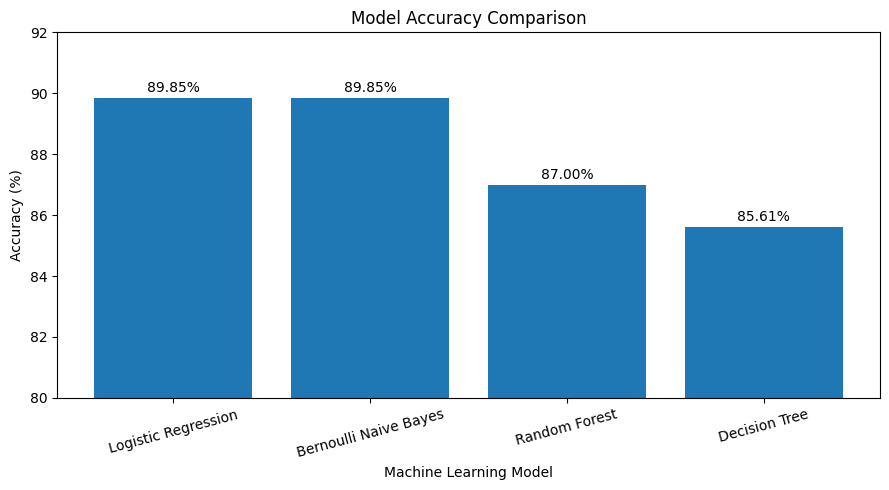

In [25]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"] * 100
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(80, 92)

plt.xticks(rotation=15)

for i, value in enumerate(results_df["Accuracy"] * 100):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

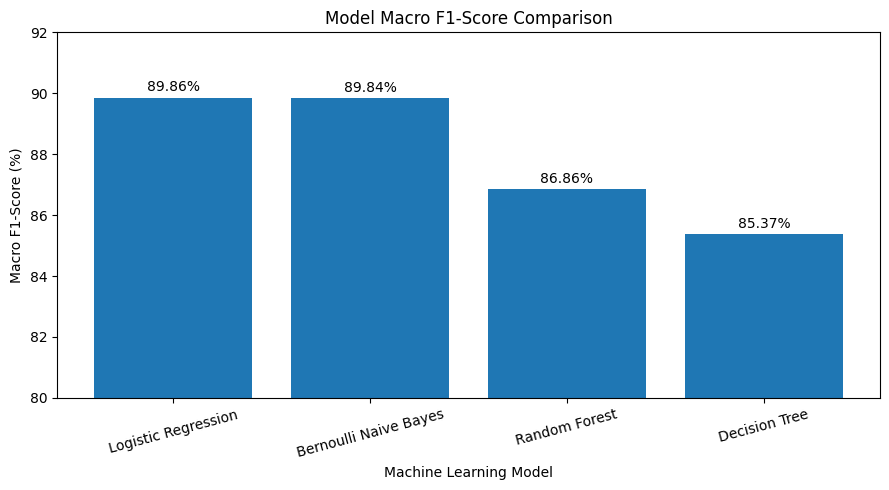

In [26]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["F1 Score (Macro)"] * 100
)

plt.title("Model Macro F1-Score Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Macro F1-Score (%)")
plt.ylim(80, 92)

plt.xticks(rotation=15)

for i, value in enumerate(results_df["F1 Score (Macro)"] * 100):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [27]:
import joblib

In [28]:
# Paths for model artifacts
MODEL_PATH = MODEL_DIR / "disease_prediction_model.pkl"
ENCODER_PATH = MODEL_DIR / "label_encoder.pkl"
FEATURES_PATH = MODEL_DIR / "symptom_features.pkl"

# Save the final Logistic Regression model
joblib.dump(logistic_model, MODEL_PATH)

# Save the fitted LabelEncoder
joblib.dump(label_encoder, ENCODER_PATH)

# Save symptom names in the exact training order
joblib.dump(X.columns.tolist(), FEATURES_PATH)

print("Model artifacts saved successfully!")
print("Model:", MODEL_PATH)
print("Label Encoder:", ENCODER_PATH)
print("Symptom Features:", FEATURES_PATH)

Model artifacts saved successfully!
Model: c:\Users\mohit\OneDrive\Desktop\AI HealthCare\models\disease_prediction_model.pkl
Label Encoder: c:\Users\mohit\OneDrive\Desktop\AI HealthCare\models\label_encoder.pkl
Symptom Features: c:\Users\mohit\OneDrive\Desktop\AI HealthCare\models\symptom_features.pkl


In [29]:
loaded_model = joblib.load(MODEL_PATH)
loaded_encoder = joblib.load(ENCODER_PATH)
loaded_features = joblib.load(FEATURES_PATH)

print("Artifacts loaded successfully!")
print("Number of symptoms:", len(loaded_features))
print("Number of diseases:", len(loaded_encoder.classes_))

Artifacts loaded successfully!
Number of symptoms: 230
Number of diseases: 100


In [30]:
sample = X_test.iloc[[0]]

predicted_class = loaded_model.predict(sample)[0]
predicted_disease = loaded_encoder.inverse_transform(
    [predicted_class]
)[0]

actual_class = y_test[0]
actual_disease = loaded_encoder.inverse_transform(
    [actual_class]
)[0]

print("Actual Disease   :", actual_disease)
print("Predicted Disease:", predicted_disease)

Actual Disease   : allergy
Predicted Disease: allergy
